# Experimento 5 — Elo pré-torneio

Adicionamos **EloDiff** às cinco features do Experimento 4: SeedDif, WinRateDiff,
AvgPointsForDiff, AvgPointsAgainstDiff e OppWinRateDiff. WinRate usa a temporada inteira.
Todas as estatísticas pertencem à mesma temporada do confronto e usam exclusivamente
jogos regulares anteriores ao NCAA Tournament.

O Elo começa em **1500 para cada time em cada temporada**, com **K = 20**, escala 400,
sem vantagem de mando e sem margem de vitória. Processamos Season e DayNum em ordem
crescente; jogos no mesmo dia preservam a ordem do arquivo. Para o vencedor:

`E = 1 / (1 + 10 ** ((EloPerdedor - EloVencedor) / 400))`

Somamos `20 * (1 - E)` ao vencedor e subtraímos o mesmo valor do perdedor, usando os
ratings anteriores ao jogo. Guardamos o Elo final pré-torneio. **EloDiff = EloA - EloB**,
com TeamA < TeamB. Nenhum rating passa de uma temporada para outra.

## Configuração

Reutilizamos os criadores de modelos e a validação de `src/tuning.py`.
Busca: duas opções de intercepto na regressão linear e 30 trials para cada modelo de árvores,
nos mesmos espaços dos experimentos 2/3.

Validação expansiva: 2021–2025, sempre treinando em temporadas anteriores. Para 2021,
o último torneio de treino é 2019, pois não houve torneio em 2020.
O objetivo é a média simples dos cinco scores anuais combinados M/W. Masculino e
feminino são treinados separadamente, com a mesma configuração por família de modelo.


In [1]:
from pathlib import Path
import sys
import json
from importlib.metadata import version

import numpy as np
import pandas as pd
import optuna
from IPython.display import display

pasta_atual = Path.cwd().resolve()
raiz = next(
    (p for p in [pasta_atual, *pasta_atual.parents] if (p / "raw_data").is_dir()),
    None,
)
if raiz is None:
    raise FileNotFoundError("Pasta raw_data não encontrada.")
if str(raiz) not in sys.path:
    sys.path.insert(0, str(raiz))

from src.data_processing import carregar_dados, preparar_seeds, organizar_jogos
from src.features import adicionar_seeds, calcular_winrate, adicionar_winrate
from src.models import criar_regressao_linear, criar_random_forest, criar_xgboost
from src.tuning import otimizar_modelo
from src.submission import preparar_confrontos, prever_confrontos, salvar_submission

EXPERIMENTO = "exp5_elo"
FEATURES = ["SeedDif", "WinRateDiff", "AvgPointsForDiff", "AvgPointsAgainstDiff", "OppWinRateDiff", "EloDiff"]
ANOS_VALIDACAO = list(range(2021, 2026))
TEMPORADA_PREVISAO = 2026
SEED = 42
N_JOBS_MODELO = 2
CATEGORIAS = {"M": "Masculino", "W": "Feminino"}
CRIADORES = {
    "linear": criar_regressao_linear,
    "random_forest": criar_random_forest,
    "xgboost": criar_xgboost,
}
NOMES = {"linear": "Regressão linear", "random_forest": "Random Forest", "xgboost": "XGBoost"}
N_TRIALS = {"linear": 2, "random_forest": 30, "xgboost": 30}
PARAMETROS_FIXOS = {
    "linear": {},
    "random_forest": {"random_state": SEED, "n_jobs": N_JOBS_MODELO},
    "xgboost": {
        "random_state": SEED, "n_jobs": N_JOBS_MODELO,
        "objective": "reg:squarederror", "tree_method": "hist",
    },
}
ESPACOS = {
    "linear": {
        "fit_intercept": {"tipo": "categorical", "choices": [False, True]},
    },
    "random_forest": {
        "n_estimators": {"tipo": "int", "low": 150, "high": 500, "step": 50},
        "max_depth": {"tipo": "categorical", "choices": [2, 3, 4, 6, 8, 12, None]},
        "min_samples_leaf": {"tipo": "int", "low": 2, "high": 80, "log": True},
        "max_features": {"tipo": "categorical", "choices": [0.5, 1.0]},
        "max_samples": {"tipo": "float", "low": 0.6, "high": 1.0},
    },
    "xgboost": {
        "n_estimators": {"tipo": "int", "low": 100, "high": 600, "step": 50},
        "max_depth": {"tipo": "int", "low": 1, "high": 5},
        "learning_rate": {"tipo": "float", "low": 0.01, "high": 0.15, "log": True},
        "min_child_weight": {"tipo": "float", "low": 5.0, "high": 80.0, "log": True},
        "subsample": {"tipo": "float", "low": 0.6, "high": 1.0},
        "colsample_bytree": {"tipo": "categorical", "choices": [0.5, 1.0]},
        "reg_alpha": {"tipo": "float", "low": 0.00001, "high": 10.0, "log": True},
        "reg_lambda": {"tipo": "float", "low": 0.1, "high": 100.0, "log": True},
        "gamma": {"tipo": "float", "low": 0.0, "high": 5.0},
    },
}
optuna.logging.set_verbosity(optuna.logging.WARNING)

from src.features import calcular_estatisticas_agregadas, adicionar_estatisticas
from src.tuning import avaliar_temporadas
LIMITE_DAYNUM_PREVISAO = 134


from src.features import calcular_elo, adicionar_elo
FEATURES_EXP4 = FEATURES[:-1]
K_ELO = 20
ELO_INICIAL = 1500

REFERENCIA_EXP4 = json.loads(r'''{"melhores_parametros": {"linear": {"fit_intercept": true}, "random_forest": {"random_state": 42, "n_jobs": 2, "n_estimators": 500, "max_depth": 4, "min_samples_leaf": 6, "max_features": 0.5, "max_samples": 0.6065760550178787}, "xgboost": {"random_state": 42, "n_jobs": 2, "objective": "reg:squarederror", "tree_method": "hist", "n_estimators": 150, "max_depth": 3, "learning_rate": 0.012689764289026415, "min_child_weight": 8.607635238510117, "subsample": 0.6580133184316654, "colsample_bytree": 0.5, "reg_alpha": 0.0024896301334778855, "reg_lambda": 2.8889382262130026, "gamma": 0.6608413857851283}}, "melhores_medias": {"linear": 0.07102647699289884, "random_forest": 0.06868149782959243, "xgboost": 0.06756812913405244}, "versoes": {"numpy": "2.2.6", "pandas": "2.3.2", "scikit-learn": "1.7.1", "xgboost": "3.0.5", "optuna": "4.9.0"}, "fonte": "notebooks\\features_incrementais\\exp4_features_agregadas.ipynb: registro do experimento"}''')


## Preparar dados e verificar separação temporal

Carregamos exclusivamente `M/WRegularSeasonCompactResults.csv` para calcular as estatísticas.
Os resultados NCAA servem para os targets, os cortes históricos por DayNum e auditoria;
nenhum placar do torneio entra no cálculo das features.

Para cada temporada histórica, o limite exclusivo é o primeiro DayNum do torneio
daquela categoria. Para 2026 usamos o mesmo limite dos notebooks anteriores: **DayNum < 134**.
As funções rejeitam jogos fora do recorte. Não descartamos silenciosamente jogos
históricos com features ausentes.


In [2]:
dados = {
    categoria: carregar_dados(raiz / "raw_data", categoria, incluir_regular=True)
    for categoria in CATEGORIAS
}
assert set(dados["M"]["times"]["TeamID"]).isdisjoint(set(dados["W"]["times"]["TeamID"]))
seeds, estatisticas, elos, jogos, limites, auditoria = {}, {}, {}, {}, {}, []
for categoria, base in dados.items():
    torneios = base["resultados"].loc[base["resultados"]["Season"] < TEMPORADA_PREVISAO].copy()
    limites[categoria] = torneios.groupby("Season")["DayNum"].min().to_dict()
    limites[categoria][TEMPORADA_PREVISAO] = LIMITE_DAYNUM_PREVISAO
    regulares = base["temporada_regular"].loc[
        base["temporada_regular"]["Season"].isin(limites[categoria])
    ].copy()
    assert (regulares["DayNum"] < regulares["Season"].map(limites[categoria])).all()
    assert regulares.merge(
        torneios[["Season", "DayNum", "WTeamID", "LTeamID"]],
        on=["Season", "DayNum", "WTeamID", "LTeamID"],
    ).empty, "Sobreposição entre jogos regulares e NCAA."
    ids_categoria = set(base["times"]["TeamID"])
    assert regulares["WTeamID"].isin(ids_categoria).all()
    assert regulares["LTeamID"].isin(ids_categoria).all()

    seeds[categoria] = preparar_seeds(base["seeds"])
    estatisticas[categoria] = calcular_estatisticas_agregadas(
        regulares, limites_daynum=limites[categoria],
    )
    elos[categoria] = calcular_elo(
        regulares, limites_daynum=limites[categoria], k=K_ELO, elo_inicial=ELO_INICIAL,
    )
    assert not elos[categoria].duplicated(["Season", "TeamID"]).any()
    totais = elos[categoria].groupby("Season")["Elo"].agg(["sum", "size"])
    np.testing.assert_allclose(totais["sum"], totais["size"] * ELO_INICIAL)
    # Compatibilidade do win rate de temporada inteira com o Experimento 2.
    taxas_antigas = calcular_winrate(regulares).set_index(["Season", "TeamID"])
    stats_index = estatisticas[categoria].set_index(["Season", "TeamID"])
    np.testing.assert_allclose(stats_index["WinRate"], taxas_antigas.loc[stats_index.index, "WinRate"])
    assert not estatisticas[categoria].duplicated(["Season", "TeamID"]).any()

    base_jogos = adicionar_seeds(organizar_jogos(torneios), seeds[categoria])
    jogos[categoria] = adicionar_estatisticas(base_jogos, estatisticas[categoria])
    jogos[categoria] = adicionar_elo(jogos[categoria], elos[categoria])
    tabela = jogos[categoria]
    assert len(tabela) == len(torneios)
    assert (tabela["TeamA"] < tabela["TeamB"]).all()
    assert tabela["Target"].equals(tabela["ScoreA"] - tabela["ScoreB"])
    assert tabela["SeedDif"].equals(tabela["SeedA"] - tabela["SeedB"])
    assert np.isfinite(tabela[FEATURES].to_numpy()).all()
    assert tabela["TeamA"].isin(ids_categoria).all() and tabela["TeamB"].isin(ids_categoria).all()
    chave_a = pd.MultiIndex.from_frame(tabela[["Season", "TeamA"]])
    chave_b = pd.MultiIndex.from_frame(tabela[["Season", "TeamB"]])
    for nome in ["WinRate", "AvgPointsFor", "AvgPointsAgainst", "OppWinRate"]:
        esperado = stats_index[nome].reindex(chave_a).to_numpy() - stats_index[nome].reindex(chave_b).to_numpy()
        np.testing.assert_allclose(tabela[f"{nome}Diff"], esperado)

    elo_index = elos[categoria].set_index(["Season", "TeamID"])["Elo"]
    np.testing.assert_allclose(tabela["EloDiff"],
        elo_index.reindex(chave_a).to_numpy() - elo_index.reindex(chave_b).to_numpy())

    for ano, grupo in regulares.groupby("Season"):
        auditoria.append({
            "Categoria": categoria, "Season": ano, "JogosRegulares": len(grupo),
            "UltimoDayNumRegular": grupo["DayNum"].max(), "LimiteExclusivo": limites[categoria][ano],
        })

auditoria = pd.DataFrame(auditoria)
display(auditoria.loc[auditoria["Season"] >= min(ANOS_VALIDACAO)])
divisoes = pd.DataFrame([
    {
        "AnoValidacao": ano, "Categoria": CATEGORIAS[categoria],
        "UltimoAnoTreino": tabela.loc[tabela["Season"] < ano, "Season"].max(),
        "JogosTreino": tabela["Season"].lt(ano).sum(),
        "JogosValidacao": tabela["Season"].eq(ano).sum(),
    }
    for ano in ANOS_VALIDACAO for categoria, tabela in jogos.items()
])
assert divisoes["JogosValidacao"].gt(0).all()
assert (divisoes["UltimoAnoTreino"] < divisoes["AnoValidacao"]).all()
assert divisoes.loc[divisoes["AnoValidacao"].eq(2021), "UltimoAnoTreino"].eq(2019).all()
display(divisoes)
display(jogos["M"][["Season", "TeamA", "TeamB", *FEATURES, "Target"]].head())


,Categoria,Season,JogosRegulares,UltimoDayNumRegular,LimiteExclusivo
35,M,2021,3855,132,136
36,M,2022,5345,132,134
37,M,2023,5602,132,134
38,M,2024,5607,132,134
39,M,2025,5641,132,134
40,M,2026,5647,132,134
63,W,2021,3556,132,139
64,W,2022,5060,132,135
65,W,2023,5374,132,135
66,W,2024,5414,132,135


,AnoValidacao,Categoria,UltimoAnoTreino,JogosTreino,JogosValidacao
0,2021,Masculino,2019,2251,66
1,2021,Feminino,2019,1386,63
2,2022,Masculino,2021,2317,67
3,2022,Feminino,2021,1449,67
4,2023,Masculino,2022,2384,67
5,2023,Feminino,2022,1516,67
6,2024,Masculino,2023,2451,67
7,2024,Feminino,2023,1583,67
8,2025,Masculino,2024,2518,67
9,2025,Feminino,2024,1650,67


,Season,TeamA,TeamB,SeedDif,WinRateDiff,AvgPointsForDiff,AvgPointsAgainstDiff,OppWinRateDiff,EloDiff,Target
0,1985,1116,1234,1,-0.030303,-4.400000,2.430303,0.020862,-0.563602,9
1,1985,1120,1345,5,-0.059310,1.224828,1.335172,0.002403,-17.506832,1
2,1985,1207,1250,-15,0.546616,9.982120,-10.132822,0.131907,234.650780,25
3,1985,1229,1425,1,0.062169,3.199735,1.022487,-0.033687,13.613385,3
4,1985,1242,1325,-11,0.025926,8.477778,7.400000,0.065588,18.192012,11


## Optuna — Experimento 5

Cada tentativa faz dez ajustes: duas categorias × cinco anos. Todas avaliam todos
os anos, sem pruning. A configuração vencedora é reavaliada pelo módulo de tuning.
As tentativas ficam acessíveis em memória em `buscas[nome]["estudo"]`.


In [3]:
buscas = {}
for nome, criar_modelo in CRIADORES.items():
    sampler = (
        optuna.samplers.GridSampler({"fit_intercept": [False, True]}, seed=SEED)
        if nome == "linear" else optuna.samplers.TPESampler(seed=SEED)
    )
    buscas[nome] = otimizar_modelo(
        jogos, criar_modelo, ESPACOS[nome], ANOS_VALIDACAO,
        features=FEATURES, n_trials=N_TRIALS[nome],
        parametros_fixos=PARAMETROS_FIXOS[nome], sampler=sampler,
        seed=SEED, nome=f"exp5_{nome}",
    )

resumo = pd.DataFrame([
    {
        "Modelo": NOMES[nome], "MediaLogisticBrier": resultado["media"],
        "MelhorTrial": resultado["estudo"].best_trial.number,
        "Tentativas": len(resultado["estudo"].trials),
        "Parametros": json.dumps(resultado["parametros"], ensure_ascii=False),
    }
    for nome, resultado in buscas.items()
]).sort_values("MediaLogisticBrier")
display(resumo)
for nome, resultado in buscas.items():
    print(NOMES[nome], resultado["parametros"])


exp5_linear: 2/2; melhor média = 0.070656
exp5_random_forest: 5/30; melhor média = 0.069891
exp5_random_forest: 10/30; melhor média = 0.069841
exp5_random_forest: 15/30; melhor média = 0.069193
exp5_random_forest: 20/30; melhor média = 0.069193
exp5_random_forest: 25/30; melhor média = 0.069154
exp5_random_forest: 30/30; melhor média = 0.069154
exp5_xgboost: 5/30; melhor média = 0.068034
exp5_xgboost: 10/30; melhor média = 0.068034
exp5_xgboost: 15/30; melhor média = 0.068034
exp5_xgboost: 20/30; melhor média = 0.068034
exp5_xgboost: 25/30; melhor média = 0.068034
exp5_xgboost: 30/30; melhor média = 0.068034


,Modelo,MediaLogisticBrier,MelhorTrial,Tentativas,Parametros
2,XGBoost,0.068034,4,30,"{""random_state"": 42, ""n_jobs"": 2, ""objective"":..."
1,Random Forest,0.069154,23,30,"{""random_state"": 42, ""n_jobs"": 2, ""n_estimator..."
0,Regressão linear,0.070656,0,2,"{""fit_intercept"": true}"


Regressão linear {'fit_intercept': True}
Random Forest {'random_state': 42, 'n_jobs': 2, 'n_estimators': 400, 'max_depth': 4, 'min_samples_leaf': 8, 'max_features': 0.5, 'max_samples': 0.644195294768407}
XGBoost {'random_state': 42, 'n_jobs': 2, 'objective': 'reg:squarederror', 'tree_method': 'hist', 'n_estimators': 150, 'max_depth': 3, 'learning_rate': 0.01097599850212944, 'min_child_weight': 62.215825966390064, 'subsample': 0.7035119926400067, 'colsample_bytree': 0.5, 'reg_alpha': 0.013194961490425657, 'reg_lambda': 4.366473592979633, 'gamma': 0.9242722776276352}


## Scores anuais e comparação Exp. 4 × Exp. 5

Reavaliamos os melhores parâmetros do Exp. 4, copiados explicitamente de seu registro,
nas mesmas divisões temporais e com suas cinco features. Não repetimos aquela busca
nem executamos o notebook antigo. Conferimos a média contra o registro original.

O Exp. 5 seleciona suas próprias configurações. Portanto, esta comparação inclui tanto
a feature quanto a mudança de hiperparâmetros; não é uma ablação com parâmetros fixos.
Todos os scores são de validação, sem usar Kaggle para seleção.


In [4]:
comparacao_exp4 = {
    nome: avaliar_temporadas(
        jogos, CRIADORES[nome](**params), ANOS_VALIDACAO, features=FEATURES_EXP4,
    )
    for nome, params in REFERENCIA_EXP4["melhores_parametros"].items()
}
for nome, resultado in comparacao_exp4.items():
    np.testing.assert_allclose(resultado["media"], REFERENCIA_EXP4["melhores_medias"][nome], rtol=1e-6)

comparacao = pd.DataFrame([
    {"Experimento": experimento, "Modelo": NOMES[nome], "MediaLogisticBrier": resultado["media"]}
    for experimento, resultados in [("Exp. 4: agregadas", comparacao_exp4), ("Exp. 5: agregadas + Elo", buscas)]
    for nome, resultado in resultados.items()
])
display(comparacao.pivot(index="Modelo", columns="Experimento", values="MediaLogisticBrier").round(6))
ganhos = pd.DataFrame([
    {"Modelo": NOMES[nome], "Exp4": comparacao_exp4[nome]["media"],
     "Exp5": resultado["media"], "GanhoExp5": comparacao_exp4[nome]["media"] - resultado["media"]}
    for nome, resultado in buscas.items()
])
display(ganhos.round(6))
print("GanhoExp5 positivo indica redução do erro frente ao Exp. 4.")

scores_anuais = pd.concat([
    resultado["resultados"].assign(Modelo=NOMES[nome])
    for nome, resultado in buscas.items()
], ignore_index=True)
display(scores_anuais.pivot(index=["Season", "Categoria"], columns="Modelo", values="Score").round(6))
scores_comparacao = pd.concat([
    resultado["resultados"].assign(Modelo=NOMES[nome], Experimento=experimento)
    for experimento, resultados in [("Exp4", comparacao_exp4), ("Exp5", buscas)]
    for nome, resultado in resultados.items()
], ignore_index=True)
display(scores_comparacao.query("Categoria == 'Combinado'").pivot(
    index="Season", columns=["Modelo", "Experimento"], values="Score",
).round(6))


Experimento,Exp. 4: agregadas,Exp. 5: agregadas + Elo
Modelo,,
Random Forest,0.068681,0.069154
Regressão linear,0.071026,0.070656
XGBoost,0.067568,0.068034


,Modelo,Exp4,Exp5,GanhoExp5
0,Regressão linear,0.071026,0.070656,0.000370
1,Random Forest,0.068681,0.069154,-0.000472
2,XGBoost,0.067568,0.068034,-0.000466


GanhoExp5 positivo indica redução do erro frente ao Exp. 4.


Modelo            Random Forest  Regressão linear   XGBoost
Season Categoria                                           
2021   Combinado       0.082607          0.088854  0.079095
       M               0.094871          0.099058  0.089637
       W               0.069758          0.078164  0.068052
2022   Combinado       0.078290          0.077643  0.074285
       M               0.081330          0.089074  0.078943
       W               0.075250          0.066212  0.069628
2023   Combinado       0.078985          0.080124  0.075102
       M               0.089027          0.092219  0.085515
       W               0.068943          0.068029  0.064689
2024   Combinado       0.053711          0.059483  0.056700
       M               0.070201          0.078886  0.073895
       W               0.037221          0.040081  0.039504
2025   Combinado       0.052175          0.047177  0.054989
       M               0.051956          0.050141  0.056640
       W               0.052394          0.044213  0.053338

Modelo,Regressão linear,Random Forest,XGBoost,Regressão linear,Random Forest,XGBoost
Experimento,Exp4,Exp4,Exp4,Exp5,Exp5,Exp5
Season,,,,,,
2021,0.089326,0.082348,0.081031,0.088854,0.082607,0.079095
2022,0.077999,0.077747,0.073609,0.077643,0.078290,0.074285
2023,0.078583,0.076542,0.072668,0.080124,0.078985,0.075102
2024,0.060232,0.054362,0.057005,0.059483,0.053711,0.056700
2025,0.048993,0.052409,0.053528,0.047177,0.052175,0.054989


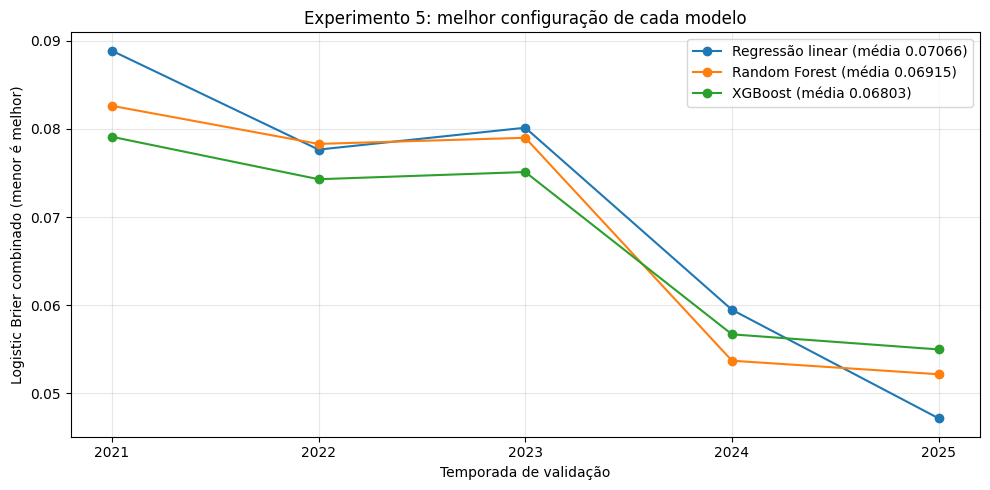

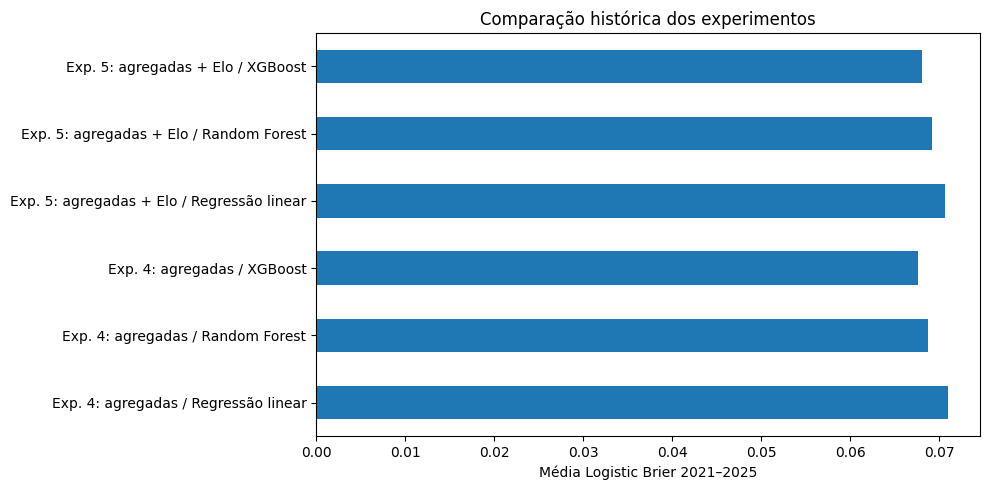

In [5]:
import matplotlib.pyplot as plt

fig_anos, ax = plt.subplots(figsize=(10, 5))
for nome, resultado in buscas.items():
    anual = resultado["resultados"].query("Categoria == 'Combinado'")
    ax.plot(anual["Season"], anual["Score"], marker="o", label=f"{NOMES[nome]} (média {resultado['media']:.5f})")
ax.set_title("Experimento 5: melhor configuração de cada modelo")
ax.set_xlabel("Temporada de validação")
ax.set_ylabel("Logistic Brier combinado (menor é melhor)")
ax.set_xticks(ANOS_VALIDACAO)
ax.grid(alpha=0.3)
ax.legend()
fig_anos.tight_layout()
plt.show()

fig_comparacao, ax = plt.subplots(figsize=(10, 5))
comparacao.assign(Rotulo=lambda t: t["Experimento"] + " / " + t["Modelo"]).plot.barh(
    x="Rotulo", y="MediaLogisticBrier", ax=ax, legend=False,
)
ax.set_xlabel("Média Logistic Brier 2021–2025")
ax.set_ylabel("")
ax.set_title("Comparação histórica dos experimentos")
fig_comparacao.tight_layout()
plt.show()


## Treino final e submissões de 2026

Treinamos novamente cada família e categoria com todo o histórico até 2025 e os
parâmetros selecionados. As estatísticas de 2026 vêm exclusivamente da temporada
regular de 2026 antes do limite.

Somente pares sem duas seeds podem usar o fallback zero. Qualquer feature ausente
entre dois participantes interrompe a execução. Verificamos IDs, ordem, finitude
e diferenças A − B. O CSV contém margens brutas, sem sigmoid.


In [6]:
sample_submission = dados["M"]["sample_submission"]
confrontos = preparar_confrontos(
    sample_submission, seeds["M"], seeds["W"],
    dados["M"]["times"]["TeamID"], dados["W"]["times"]["TeamID"],
    temporada=TEMPORADA_PREVISAO,
)
stats_2026 = pd.concat([
    stats.loc[stats["Season"].eq(TEMPORADA_PREVISAO)]
    for stats in estatisticas.values()
], ignore_index=True)
confrontos = adicionar_estatisticas(confrontos, stats_2026, permitir_ausentes=True)
elos_2026 = pd.concat([
    tabela.loc[tabela["Season"].eq(TEMPORADA_PREVISAO)] for tabela in elos.values()
], ignore_index=True)
confrontos = adicionar_elo(confrontos, elos_2026, permitir_ausentes=True)
participantes = confrontos["TemDuasSeeds"]
assert (confrontos["TeamA"] < confrontos["TeamB"]).all()
assert np.isfinite(confrontos.loc[participantes, FEATURES].to_numpy()).all()
stats_index = stats_2026.set_index(["Season", "TeamID"])
pares = confrontos.loc[participantes]
for nome in ["WinRate", "AvgPointsFor", "AvgPointsAgainst", "OppWinRate"]:
    a = stats_index[nome].reindex(pd.MultiIndex.from_frame(pares[["Season", "TeamA"]])).to_numpy()
    b = stats_index[nome].reindex(pd.MultiIndex.from_frame(pares[["Season", "TeamB"]])).to_numpy()
    np.testing.assert_allclose(pares[f"{nome}Diff"], a - b)

elo_index = elos_2026.set_index(["Season", "TeamID"])["Elo"]
np.testing.assert_allclose(pares["EloDiff"],
    elo_index.reindex(pd.MultiIndex.from_frame(pares[["Season", "TeamA"]])).to_numpy()
    - elo_index.reindex(pd.MultiIndex.from_frame(pares[["Season", "TeamB"]])).to_numpy())

modelos_finais, arquivos_submission, resumo_submissions = {}, {}, []
for nome, criar_modelo in CRIADORES.items():
    modelos_finais[nome] = {}
    for categoria, tabela in jogos.items():
        treino = tabela.loc[tabela["Season"] < TEMPORADA_PREVISAO]
        assert treino["Season"].max() == 2025
        assert treino["TeamA"].isin(dados[categoria]["times"]["TeamID"]).all()
        assert treino["TeamB"].isin(dados[categoria]["times"]["TeamID"]).all()
        modelo = criar_modelo(**buscas[nome]["parametros"])
        modelo.fit(treino[FEATURES], treino["Target"])
        modelos_finais[nome][categoria] = modelo
    assert modelos_finais[nome]["M"] is not modelos_finais[nome]["W"]
    previsoes = prever_confrontos(
        confrontos, modelos_finais[nome]["M"], modelos_finais[nome]["W"], features=FEATURES,
    )
    assert previsoes.loc[~participantes, "Pred"].eq(0).all()
    assert previsoes["ID"].equals(sample_submission["ID"])
    caminho = salvar_submission(
        previsoes, sample_submission,
        raiz / "submissions" / f"submission_exp5_elo_{nome}_{TEMPORADA_PREVISAO}.csv",
    )
    arquivos_submission[nome] = caminho
    resumo_submissions.append({
        "Modelo": NOMES[nome], "Arquivo": caminho.name,
        "Linhas": len(previsoes), "ParesParticipantes": int(participantes.sum()),
        "MinPred": previsoes["Pred"].min(), "MaxPred": previsoes["Pred"].max(),
    })
display(pd.DataFrame(resumo_submissions))


,Modelo,Arquivo,Linhas,ParesParticipantes,MinPred,MaxPred
0,Regressão linear,submission_exp5_elo_linear_2026.csv,132133,4556,-50.371783,55.420410
1,Random Forest,submission_exp5_elo_random_forest_2026.csv,132133,4556,-39.680460,44.340561
2,XGBoost,submission_exp5_elo_xgboost_2026.csv,132133,4556,-26.653881,30.776796


In [7]:
registro = {
    "experimento": EXPERIMENTO, "features": FEATURES, "anos_validacao": ANOS_VALIDACAO,
    "temporada_previsao": TEMPORADA_PREVISAO, "limite_daynum_2026": LIMITE_DAYNUM_PREVISAO,
    "objetivo": "Media simples dos scores anuais combinados M/W",
    "seed": SEED, "n_trials": N_TRIALS, "espacos_busca": ESPACOS,
    "parametros_fixos": PARAMETROS_FIXOS,
    "melhores_parametros": {nome: r["parametros"] for nome, r in buscas.items()},
    "melhores_medias": {nome: r["media"] for nome, r in buscas.items()},
    "scores_anuais": scores_anuais.to_dict(orient="records"),
    "comparacao": comparacao.to_dict(orient="records"),
    "referencia_exp4": REFERENCIA_EXP4,
    "elo": {"inicial": ELO_INICIAL, "k": K_ELO, "escala": 400, "reset_por_temporada": True,
            "mando": False, "margem_vitoria": False, "fonte": "RegularSeasonCompactResults"},
    "versoes": {p: version(p) for p in ["numpy", "pandas", "scikit-learn", "xgboost", "optuna"]},
    "arquivos_submission": {nome: str(path.relative_to(raiz)) for nome, path in arquivos_submission.items()},
}
display(registro)


{'experimento': 'exp5_elo',
 'features': ['SeedDif',
  'WinRateDiff',
  'AvgPointsForDiff',
  'AvgPointsAgainstDiff',
  'OppWinRateDiff',
  'EloDiff'],
 'anos_validacao': [2021, 2022, 2023, 2024, 2025],
 'temporada_previsao': 2026,
 'limite_daynum_2026': 134,
 'objetivo': 'Media simples dos scores anuais combinados M/W',
 'seed': 42,
 'n_trials': {'linear': 2, 'random_forest': 30, 'xgboost': 30},
 'espacos_busca': {'linear': {'fit_intercept': {'tipo': 'categorical',
    'choices': [False, True]}},
  'random_forest': {'n_estimators': {'tipo': 'int',
    'low': 150,
    'high': 500,
    'step': 50},
   'max_depth': {'tipo': 'categorical', 'choices': [2, 3, 4, 6, 8, 12, None]},
   'min_samples_leaf': {'tipo': 'int', 'low': 2, 'high': 80, 'log': True},
   'max_features': {'tipo': 'categorical', 'choices': [0.5, 1.0]},
   'max_samples': {'tipo': 'float', 'low': 0.6, 'high': 1.0}},
  'xgboost': {'n_estimators': {'tipo': 'int',
    'low': 100,
    'high': 600,
    'step': 50},
   'max_depth':